In [57]:
from nemo.collections.tts.models import T5TTS_Model
from nemo.collections.tts.data.text_to_speech_dataset import T5TTSDataset, DatasetSample
from omegaconf.omegaconf import OmegaConf, open_dict
import torch
import os
import soundfile as sf
from IPython.display import display, Audio
import numpy as np
import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"]="0"

### Checkpoint Paths

In [58]:
# Checkpoint and Hparams Paths
# hparams_file = "/datap/misc/icml2025_base_checkpoints/RoyCheckpoints/CML_WithRivaSpanish_NoPolishPortugese_SeparateCharTokenizer_hparams.yaml"
# checkpoint_file = "/datap/misc/icml2025_base_checkpoints/RoyCheckpoints/SeparateCharTokenizer_epoch12_fp32_DPO_3epochs_AllLanguages_0.05_ng1_epoch3.ckpt"


# checkpoint_file = "/datap/misc/ChallengingFinetuneLocalTraining/nosynthlast.ckpt"
hparams_file = "/datap/misc/ChallengingFinetuneLocalTraining/head1hparams.yaml"
checkpoint_file = "/datap/misc/ChallengingFinetuneLocalTraining/head1_epoch248.ckpt"

# hparams_file = "/datap/misc/ChallengingFinetuneLocalTraining/mikyas_hparams.yaml"
# checkpoint_file = "/datap/misc/ChallengingFinetuneLocalTraining/mikyas.ckpt"


# hparams_file = "/datap/misc/ChallengingFinetuneLocalTraining/roy_head1.yaml"
# checkpoint_file = "/datap/misc/ChallengingFinetuneLocalTraining/royhead1_epoch23.ckpt"
# checkpoint_file = "/datap/misc/icml2025_base_checkpoints/decodercontext_small_sp_ks3CorrectWithPrior_onlyphoneme_epoch161.ckpt"

# hparams_file = "/datap/misc/icml2025_base_checkpoints/CML_WithRivaSpanish_NoPolishPortugese_SeparateCharTokenizer_hparams.yaml"
# checkpoint_file = "/datap/misc/icml2025_base_checkpoints/SeparateCharTokenizer_epoch12_fp32_DPO_3epochs_AllLanguages_0.05_ng1_epoch3.ckpt"

codecmodel_path = "/datap/misc/checkpoints/AudioCodec_21Hz_no_eliz.nemo"

# Temp out dir for saving audios
out_dir = "/datap/misc/t5tts_inference_notebook_samples"
if not os.path.exists(out_dir):
    os.makedirs(out_dir)

### Load Model

In [59]:
model_cfg = OmegaConf.load(hparams_file).cfg

with open_dict(model_cfg):
    model_cfg.codecmodel_path = codecmodel_path
    if hasattr(model_cfg, 'text_tokenizer'):
        # Backward compatibility for models trained with absolute paths in text_tokenizer
        model_cfg.text_tokenizer.g2p.phoneme_dict = "scripts/tts_dataset_files/ipa_cmudict-0.7b_nv23.01.txt"
        model_cfg.text_tokenizer.g2p.heteronyms = "scripts/tts_dataset_files/heteronyms-052722"
        model_cfg.text_tokenizer.g2p.phoneme_probability = 1.0
    model_cfg.train_ds = None
    model_cfg.validation_ds = None


model = T5TTS_Model(cfg=model_cfg)
print("Loading weights from checkpoint")
ckpt = torch.load(checkpoint_file)
model.load_state_dict(ckpt['state_dict'])
print("Loaded weights.")

model.use_kv_cache_for_inference = True

model.cuda()
model.eval()

[NeMo W 2025-02-13 10:07:56 experimental:26] `<class 'nemo.collections.tts.g2p.models.i18n_ipa.IpaG2p'>` is experimental and not ready for production yet. Use at your own risk.
[NeMo W 2025-02-13 10:07:57 i18n_ipa:124] apply_to_oov_word=None, This means that some of words will remain unchanged if they are not handled by any of the rules in self.parse_one_word(). This may be intended if phonemes and chars are both valid inputs, otherwise, you may see unexpected deletions in your input.
[NeMo W 2025-02-13 10:07:57 experimental:26] `<class 'nemo.collections.common.tokenizers.text_to_speech.tts_tokenizers.IPATokenizer'>` is experimental and not ready for production yet. Use at your own risk.
[NeMo W 2025-02-13 10:08:01 modelPT:176] If you intend to do training or fine-tuning, please call the ModelPT.setup_training_data() method and provide a valid configuration file to setup the train data loader.
    Train config : 
    dataset:
      dataset_type: tarred_vocoder
      dataset_args:
     

[NeMo I 2025-02-13 10:08:01 audio_codec:101] Vector quantizer does not support commit loss.
[NeMo I 2025-02-13 10:08:02 features:305] PADDING: 1
[NeMo I 2025-02-13 10:08:02 features:305] PADDING: 1
[NeMo I 2025-02-13 10:08:02 features:305] PADDING: 1
[NeMo I 2025-02-13 10:08:02 features:305] PADDING: 1
[NeMo I 2025-02-13 10:08:02 features:305] PADDING: 1
[NeMo I 2025-02-13 10:08:02 features:305] PADDING: 1
[NeMo I 2025-02-13 10:08:02 features:305] PADDING: 1
[NeMo I 2025-02-13 10:08:02 save_restore_connector:275] Model AudioCodecModel was successfully restored from /datap/misc/checkpoints/AudioCodec_21Hz_no_eliz.nemo.
Loading weights from checkpoint
Loaded weights.


T5TTS_Model(
  (audio_embeddings): ModuleList(
    (0-7): 8 x Embedding(2048, 768)
  )
  (text_embedding): Embedding(98, 768)
  (t5_encoder): Transformer(
    (dropout): Dropout(p=0.1, inplace=False)
    (norm_out): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (layers): ModuleList(
      (0-5): 6 x TransformerLayer(
        (norm_self): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (self_attention): SelfAttention(
          (o_net): Linear(in_features=768, out_features=768, bias=False)
          (dropout): Dropout(p=0.1, inplace=False)
          (qkv_net): Linear(in_features=768, out_features=2304, bias=False)
        )
        (norm_pos_ff): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (pos_ff): PositionwiseConvFF(
          (non_linearity): GELU(approximate='tanh')
          (proj): ConvolutionLayer(
            (conv): Conv1d(768, 3072, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
          )
          (o_net): ConvolutionLay

### Initialize Dataset class and helper functions

In [60]:
test_dataset = T5TTSDataset(
    dataset_meta={},
    sample_rate=model_cfg.sample_rate,
    min_duration=0.5,
    max_duration=20,
    codec_model_downsample_factor=model_cfg.codec_model_downsample_factor,
    bos_id=model.bos_id,
    eos_id=model.eos_id,
    context_audio_bos_id=model.context_audio_bos_id,
    context_audio_eos_id=model.context_audio_eos_id,
    audio_bos_id=model.audio_bos_id,
    audio_eos_id=model.audio_eos_id,
    num_audio_codebooks=model_cfg.num_audio_codebooks,
    prior_scaling_factor=None,
    load_cached_codes_if_available=True,
    dataset_type='test',
    tokenizer_config=None,
    load_16khz_audio=model.model_type == 'single_encoder_sv_tts',
    use_text_conditioning_tokenizer=model.use_text_conditioning_encoder,
    pad_context_text_to_max_duration=model.pad_context_text_to_max_duration,
    context_duration_min=model.cfg.get('context_duration_min', 5.0),
    context_duration_max=model.cfg.get('context_duration_max', 5.0),
)
test_dataset.text_tokenizer, test_dataset.text_conditioning_tokenizer = model._setup_tokenizers(model.cfg, mode='test')



def get_audio_duration(file_path):
    with sf.SoundFile(file_path) as audio_file:
        # Calculate the duration
        duration = len(audio_file) / audio_file.samplerate
        return duration

def create_record(text, context_audio_filepath=None, context_text=None):
    dummy_audio_fp = os.path.join(out_dir, "dummy_audio.wav")
    dummy_audio = sf.write(dummy_audio_fp, np.zeros(22050 * 3), 22050)  # 3 seconds of silence
    record = {
        'audio_filepath' : dummy_audio_fp,
        'duration': 3.0,
        'text': text,
        'speaker': "dummy",
    }
    if context_text is not None:
        assert context_audio_filepath is None
        record['context_text'] = context_text
    else:
        assert context_audio_filepath is not None
        record['context_audio_filepath'] = context_audio_filepath
        record['context_audio_duration'] = get_audio_duration(context_audio_filepath)
    
    return record

[NeMo W 2025-02-13 10:08:11 experimental:26] `<class 'nemo.collections.tts.g2p.models.i18n_ipa.IpaG2p'>` is experimental and not ready for production yet. Use at your own risk.
[NeMo W 2025-02-13 10:08:12 i18n_ipa:124] apply_to_oov_word=None, This means that some of words will remain unchanged if they are not handled by any of the rules in self.parse_one_word(). This may be intended if phonemes and chars are both valid inputs, otherwise, you may see unexpected deletions in your input.
[NeMo W 2025-02-13 10:08:12 experimental:26] `<class 'nemo.collections.common.tokenizers.text_to_speech.tts_tokenizers.IPATokenizer'>` is experimental and not ready for production yet. Use at your own risk.


### Set transcript and context pairs to test

In [61]:
# Change sample text and prompt audio/text here
audio_base_dir = "/"
test_entries = [
    create_record(
        text="Hi. This is me. This is with a, comma. This is with a...comma.",
        context_text="Speaker and Emotion: | Language:en Dataset:Riva Speaker:Lindy_WIZWIKI |",
#         context_audio_filepath="/datap/misc/LibriTTSfromNemo/LibriTTS/test-clean/7729/102255/7729_102255_000012_000001.wav", # Supply either context_audio_filepath or context_text, not both
    ),
#     create_record(
#         text="His phone number is one one one one, nine nine nine nine nine, nine nine, nine, right",
#         context_text="Speaker and Emotion: | Language:en Dataset:Riva Speaker:Lindy_WIZWIKI |",
#     ),
#     create_record(
#         text="Let me confirm S D S D two two two two one two four four h t t p four five six seven eight. Is that correct?",
# #         context_audio_filepath="/datap/misc/LibriTTSfromNemo/LibriTTS/test-clean/3729/6852/3729_6852_000084_000003.wav", # Supply either context_audio_filepath or context_text, not both
#         context_text="Speaker and Emotion: | Language:en Dataset:Riva Speaker:Lindy_WIZWIKI |",
# #                 context_audio_filepath="/datap/misc/LibriTTSfromNemo/LibriTTS/test-clean/7729/102255/7729_102255_000012_000001.wav", # Supply either context_audio_filepath or context_text, not both
#     ),
#     create_record(
#         text="S D S D Pass zero - zero Fail - zero to zero - zero - zero Cancelled - fifty nine to three - two - sixty four Total - fifty nine to three - two -",
#         context_text="Speaker and Emotion: | Language:en Dataset:Riva Speaker:Lindy_WIZWIKI |",
# #                 context_audio_filepath="/datap/misc/LibriTTSfromNemo/LibriTTS/test-clean/7729/102255/7729_102255_000012_000001.wav", # Supply either context_audio_filepath or context_text, not both
#     ),
#     create_record(
#         text="This is an example of a regular text without any challlenging texts like repeated words or numbers just to do a sanity check.",
#         context_text="Speaker and Emotion: | Language:en Dataset:Riva Speaker:Lindy_WIZWIKI |",
# #                 context_audio_filepath="/datap/misc/LibriTTSfromNemo/LibriTTS/test-clean/7729/102255/7729_102255_000012_000001.wav", # Supply either context_audio_filepath or context_text, not both
#     ),
#     create_record(
#         text="Let me confirm one, one, one, one, one, x, two, two two, two two, two, one, two, four, four, h t t p, four, five, six, seven, eight. Is that correct?",
#         context_text="Speaker and Emotion: | Language:en Dataset:Riva Speaker:Lindy_WIZWIKI |",
# #         context_audio_filepath="/datap/misc/LibriTTSfromNemo/LibriTTS/test-clean/7729/102255/7729_102255_000012_000001.wav", # Supply either context_audio_filepath or context_text, not both
#     ),
#     create_record(
#         text="Hi, my phone number is eight five eight, two five seven, nine nine five four. Please transfer me five hundred and fifty five dollars on february seventh",
#         context_text="Speaker and Emotion: | Language:en Dataset:Riva Speaker:Lindy_WIZWIKI |",
# #                 context_audio_filepath="/datap/misc/LibriTTSfromNemo/LibriTTS/test-clean/7729/102255/7729_102255_000012_000001.wav", # Supply either context_audio_filepath or context_text, not both
#     ),

#     create_record(
#         text="To deliver interfaces that are significantly better suited to create and process R F C eight twenty one, R F C eight twenty two, R F C nine seventy seven, and MIME content.",
#         context_text="Speaker and Emotion: | Language:en Dataset:Riva Speaker:Lindy_WIZWIKI |",
# #         context_audio_filepath="/datap/misc/LibriTTSfromNemo/LibriTTS/test-clean/7729/102255/7729_102255_000012_000001.wav", # Supply either context_audio_filepath or context_text, not both
#     ),
]

data_samples = []
for entry in test_entries:
    dataset_sample = DatasetSample(
        dataset_name="sample",
        manifest_entry=entry,
        audio_dir=audio_base_dir,
        feature_dir=audio_base_dir,
        text=entry['text'],
        speaker=None,
        speaker_index=0,
        tokenizer_names=["english_phoneme"], # Change this for multilingual: "english_phoneme", "spanish_phoneme", "english_chartokenizer", "german_chartokenizer".. 
    )
    data_samples.append(dataset_sample)
    
test_dataset.data_samples = data_samples

test_data_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=1,
    collate_fn=test_dataset.collate_fn,
    num_workers=0,
    shuffle=False
)

### Generate With Prior

Processing batch 0 out of 1
Decoding timestep 0
Decoding timestep 20
Decoding timestep 40
Decoding timestep 60
Decoding timestep 80
End detected for item 0 at timestep 93
All ends reached
generation time 2.7884418964385986
Hi. This is me. This is with a, comma. This is with a...comma.
Prior Used? False


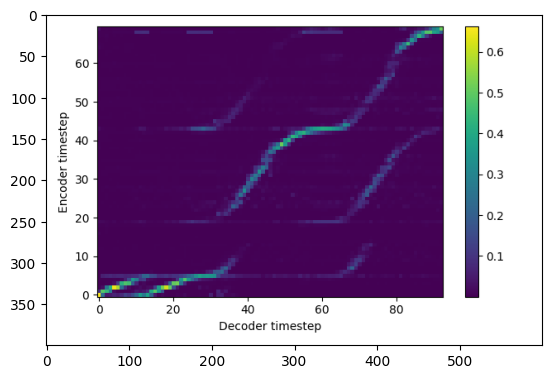

item, layer, head 0 0 0


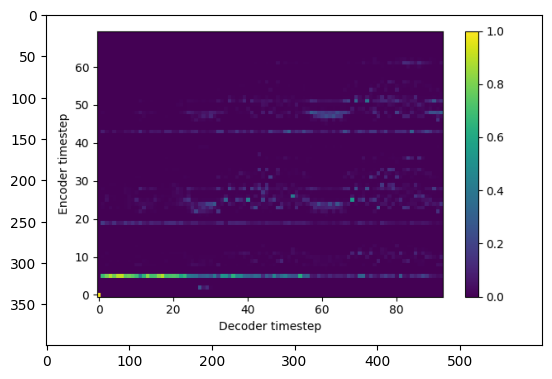

item, layer, head 0 1 0


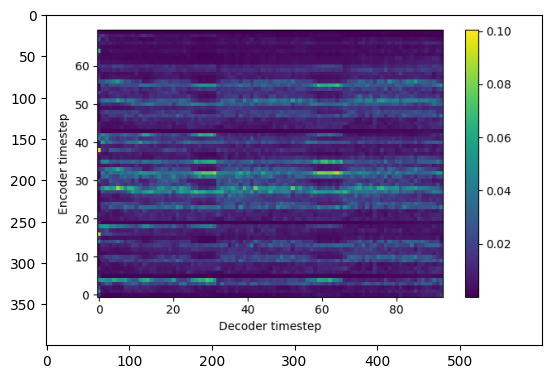

item, layer, head 0 2 0


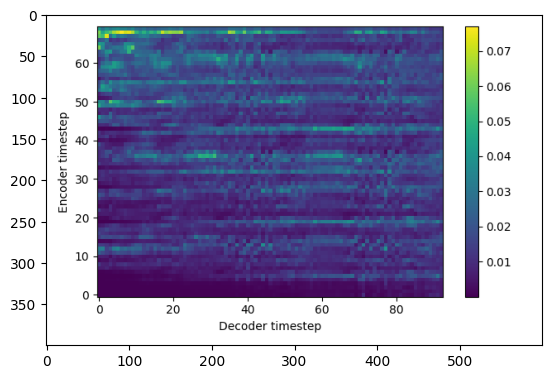

item, layer, head 0 3 0


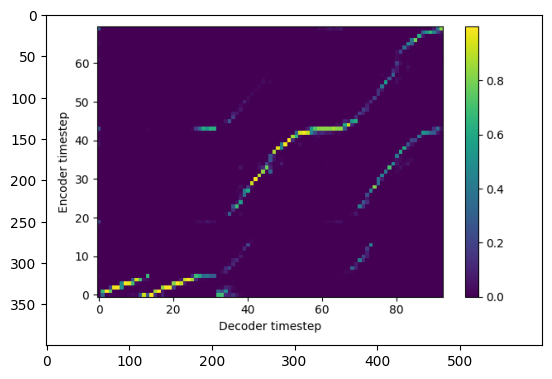

item, layer, head 0 4 0


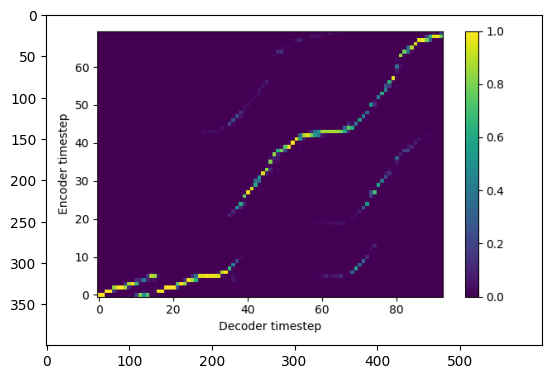

item, layer, head 0 5 0


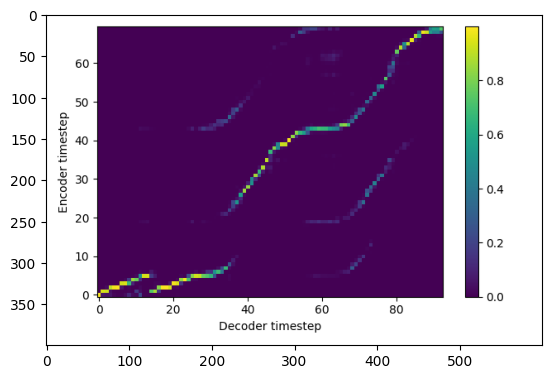

item, layer, head 0 6 0


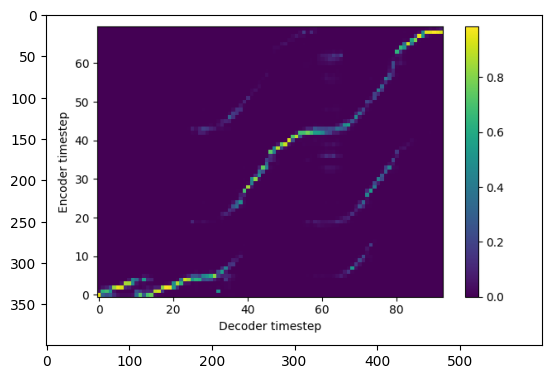

item, layer, head 0 7 0


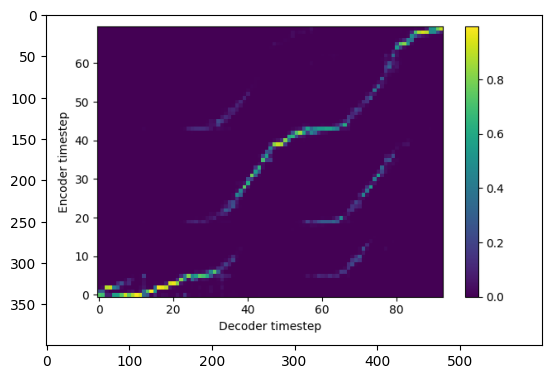

item, layer, head 0 8 0


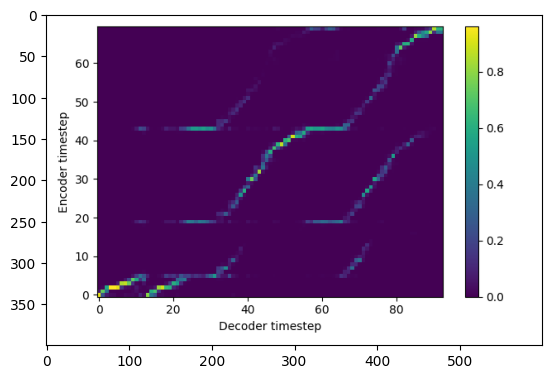

item, layer, head 0 9 0


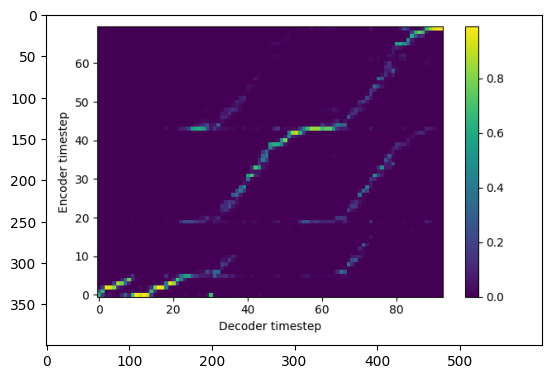

item, layer, head 0 10 0


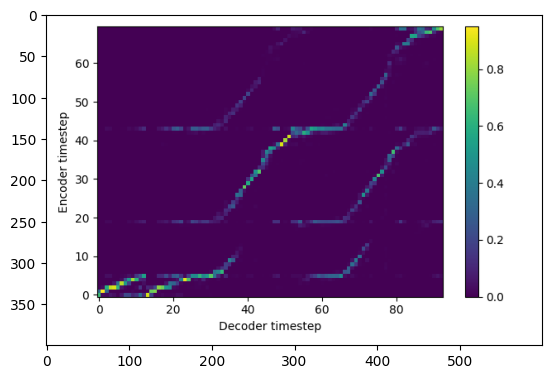

item, layer, head 0 11 0


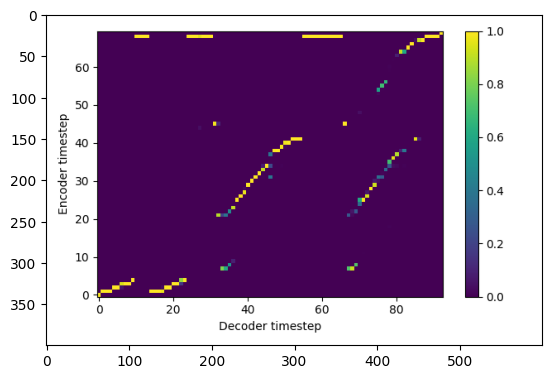

------------------------------------
------------------------------------


In [63]:
import matplotlib.pyplot as plt

item_idx = 0
for bidx, batch in enumerate(test_data_loader):
    print("Processing batch {} out of {}".format(bidx, len(test_data_loader)))
    model.t5_decoder.reset_cache(use_cache=True)
    batch_cuda ={}
    for key in batch:
        if isinstance(batch[key], torch.Tensor):
            batch_cuda[key] = batch[key].cuda()
        else:
            batch_cuda[key] = batch[key]
    import time
    st = time.time()
    
    for _ in range(1):
        for apply_prior in [False]:
            predicted_audio, predicted_audio_lens, _, _, cross_attn_np, all_heads_attn_np = model.infer_batch(
                batch_cuda, 
                max_decoder_steps=430, 
                temperature=0.7, 
                topk=80, 
                use_cfg=True,
                cfg_scale=2.5,
                prior_epsilon=1e-3,
                lookahead_window_size=10,
                return_cross_attn_probs=True,
                estimate_alignment_from_layers=[7],
                apply_attention_prior=apply_prior,
                apply_prior_to_layers=None,
                compute_all_heads_attn_maps=True,
                start_prior_after_n_audio_steps=0
            )
            print("generation time", time.time() - st)
            for idx in range(predicted_audio.size(0)):
                predicted_audio_np = predicted_audio[idx].float().detach().cpu().numpy()
                predicted_audio_np = predicted_audio_np[:predicted_audio_lens[idx]]
                audio_path = os.path.join(out_dir, f"predicted_audio_{item_idx}.wav")
                sf.write(audio_path, predicted_audio_np, model.cfg.sample_rate)
                print(test_entries[bidx]['text'])
                print("Prior Used?", apply_prior)
                display(Audio(audio_path))
                item_idx += 1
                plt.imshow(cross_attn_np[idx])
                plt.show()
                for hidx, head_cross_attn in enumerate(all_heads_attn_np[idx]):
                    layer_num = hidx // model.cfg.t5_decoder.xa_n_heads
                    head_num = hidx % model.cfg.t5_decoder.xa_n_heads
                    print("item, layer, head", idx, layer_num, head_num)
                    plt.imshow(all_heads_attn_np[idx][hidx])
                    plt.show()

            print("------------------------------------")
            print("------------------------------------")